# Mixture of Mixture of Gaussians Example

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from scipy.special import softmax, logsumexp
from copy import copy
from sklearn.preprocessing import KernelCenterer

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex, linear_kernel_mat

# Set Parameters

In [ ]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 2 #1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


# noise_sd = 1

# Generate Data

In [ ]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(-2,2,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

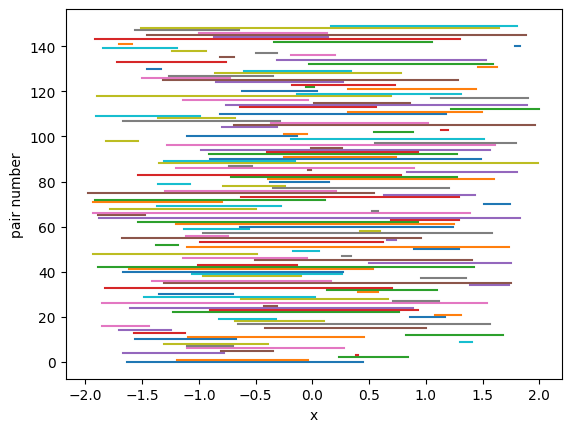

In [ ]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

# Nonlinear

In [ ]:
noise_sd_0 = .7
noise_sd_1 = .3

Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = X[component_ids==0]**3 - X[component_ids==0]
Y[(component_ids==1)] = -X[component_ids==1]**4 + X[component_ids==1]**2
Ytrue = copy(Y)
# Y = Y + np.random.normal(0, noise_sd, Y.shape)

noise_sd = np.ndarray((2*n,1))
noise_sd[(component_ids==0)] = noise_sd_0
noise_sd[(component_ids==1)] = noise_sd_1

Y = Y + np.random.normal(0, noise_sd, Y.shape)

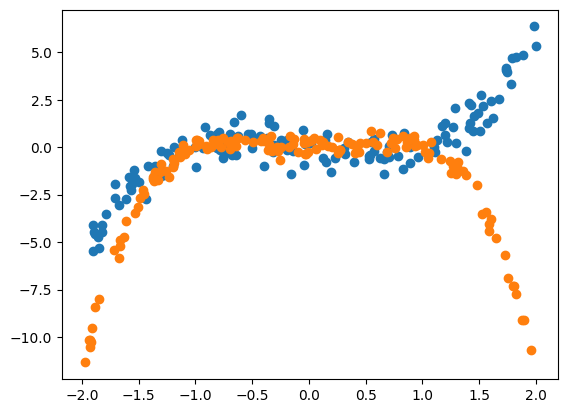

In [ ]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [ ]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [ ]:
def compute_responsibilities(x, Y, w, K, A, sigmas, M):
    
    n2 = x.shape[0] # total data points = 2*number pairs n
    
    assert n2 % 2 == 0, "n must be even for pairing"


    log_probs = []

    # --- compute per-model log probs ---
    for im in range(M):
        mu = K@A[:,im]
        Delta = (Y.squeeze() - mu) ** 2
        print("shape Y", np.shape(Y))
        print("shape mu", np.shape(mu))
        print("shape Delta", np.shape(Delta))
        
        log_likelihood = -Delta / (2 * sigmas[im]) - .5 * np.log(sigmas[im])

        log_prior = np.log(w[im])
        
        log_probs.append(log_likelihood.squeeze())
        print("shape log_probs", np.shape(log_probs))

    # shape: (n2, M)
    log_probs = np.stack(log_probs, axis=1)
    print("shape log_probs 2", np.shape(log_probs))

    # group the pairs
    log_likelihood_pairs = log_probs.reshape(n2 // 2, 2, M)
    print("shape log_probs_pairs", np.shape(log_likelihood_pairs))

    # sum within each pair (correct probabilistically)
    log_likelihood_pairwise = np.sum(log_likelihood_pairs, axis=1)  # (n2/2, M)

    log_probs_pairwise = log_likelihood_pairwise + log_prior

    # compute responsibilities at pair level
    gamma_pairwise = softmax(log_probs_pairwise, axis=1)  # (n2/2, M)

    # expand back so each pair shares gamma
    gamma = gamma_pairwise.repeat(2, axis=0)  # (n2, M)

    return gamma


In [ ]:
kern_width = 0.8

#K = linear_kernel_mat(X,X)
K = gauss_kernal_mat(X,X,sigma=kern_width)
# transformer = KernelCentere
#r().fit(K)
# K = transformer.transform(K)
w, A = scipy.sparse.linalg.eigs(K, k=M)
# w = np.real(w)
# w = w/np.sum(w)
w = np.ones(M) / M
A = np.real(A)
sigmas = np.ones(M)
s1 = sigmas[0]*np.ones(2*n)
s2 = sigmas[1]*np.ones(2*n)
sigmas_matrix = np.column_stack((s1,s2))

maxiter = 50

R = np.zeros((n,M))



Yv = Y.squeeze()          # shape: (2*n,)
n2 = Yv.shape[0]
assert n2 == 2*n

maxiter = 50
eps = 1e-8

for it in range(maxiter):
    print("iter", it)
    print("sigmas", sigmas)

    # ----------------------------------------------------
    # E-step
    # ----------------------------------------------------
    Mu = K @ A                         # shape: (2*n, M)
    Delta = (Yv[:, None] - Mu) ** 2    # shape: (2*n, M)

    log_pair = np.zeros((n, M))

    for m in range(M):
        residual_sum = Delta[0::2, m] + Delta[1::2, m]

        log_pair[:, m] = (
            np.log(w[m] ) # + eps
            - np.log(sigmas[m] ) # + eps
            - residual_sum / (2 * (sigmas[m] )) # + eps
        )

    # stable softmax over mixture components
    R_pair = np.exp(log_pair - logsumexp(log_pair, axis=1, keepdims=True)) # softmax(log_pair, axis=1) #
    # shape: (n, M)

    # observation-level responsibilities
    R_obs = np.repeat(R_pair, 2, axis=0)
    # shape: (2*n, M)

    # ----------------------------------------------------
    # M-step
    # ----------------------------------------------------

    # update mixture weights at pair level
    w = np.mean(R_pair, axis=0)

    for m in range(M):
        Rm = R_obs[:, m]                  # shape: (2*n,)
        sqrt_Rm = np.sqrt(Rm + eps) # +eps

        K_weighted = K * sqrt_Rm[:, None]
        Y_weighted = Yv * sqrt_Rm

        # Weighted least squares update for A[:, m]
        A[:, m] = lstsq_nesterov(K_weighted, Y_weighted, A[:, m])

        # Or alternatively:
        # A[:, m] = np.linalg.lstsq(K_weighted, Y_weighted, rcond=None)[0]

        resid = Yv - K @ A[:, m]

        sigmas[m] = np.sum(Rm * resid**2) / np.sum(Rm)
        #sigmas[m] = max(sigmas[m], eps)

# for i in range(maxiter):
#     print("sigmas", sigmas)
#     print(i)
#     # E-step
#     Delta = (Y - K@A)**2 #square loss for each observation for each component
#     log_pair = np.zeros((n,M))
#     # #Delta = np.exp((1/(2*noise_sd**2))*(De2lta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
#     for m in range(M):
#         residual_sum = (Delta[0::2, m] + Delta[1::2, m])
        
#         log_pair[:, m] = (
#             np.log(w[m])
#            # - np.log(2 * np.pi)
#             - np.log(sigmas[m])
#             - residual_sum / (2 * sigmas[m])
#         )

#     R = softmax(log_pair, axis=1)
#     #R = np.exp(log_pair) / np.sum(np.exp(log_pair), axis=1, keepdims=True)
#     # Delta = (np.exp( -(Delta[0::2]+Delta[1::2]) / (2*sigmas_matrix[0::2]**2)) / np.sqrt(sigmas_matrix[0::2]))*w
#     # R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T

#     #R = compute_responsibilities(X, Y, w, K, A, sigmas, M)
#     #print("shape gamma", np.shape(gamma))
    
#     # M-step
#     w = np.sum(R,axis=0) / n
#     for j in range(M):
#         #Rm = gamma[:,j]
#         Rm = np.repeat(R[:,j],2,axis=0)
#         A[:,j] = lstsq_nesterov((K.T*Rm).T, (Y.T*Rm).T, A[:,j])
#         #A[:,j] = np.linalg.lstsq((K.T*Rm).T, (Y.T*Rm).T, rcond=None)[0].flatten()
#         sigmas[j] = np.sum(Rm * ((Y - K@A[:,j]).squeeze()**2)) / (np.sum(Rm))
#         sigmas_matrix[:,j] = sigmas[j]
#         #print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))


iter 0
sigmas [1. 1.]
iter 1
sigmas [5.21016606 1.73460353]
iter 2
sigmas [3.52989643 0.75795706]
iter 3
sigmas [2.2881261  0.55292095]
iter 4
sigmas [1.37204193 0.55908265]
iter 5
sigmas [1.15822137 0.55857854]
iter 6
sigmas [1.03652983 0.55587983]
iter 7
sigmas [0.95100481 0.55352462]
iter 8
sigmas [0.88667981 0.55198209]
iter 9
sigmas [0.83718309 0.55114652]
iter 10
sigmas [0.79880235 0.55073602]
iter 11
sigmas [0.76898829 0.55044748]
iter 12
sigmas [0.74585767 0.55003038]
iter 13
sigmas [0.72797367 0.5493135 ]
iter 14
sigmas [0.71422278 0.54820339]
iter 15
sigmas [0.70373462 0.5466695 ]
iter 16
sigmas [0.69582532 0.54472557]
iter 17
sigmas [0.68995562 0.54241262]
iter 18
sigmas [0.68569909 0.53978547]
iter 19
sigmas [0.68271765 0.5369034 ]
iter 20
sigmas [0.6807426  0.53382403]
iter 21
sigmas [0.67955993 0.5305999 ]
iter 22
sigmas [0.67899884 0.52727683]
iter 23
sigmas [0.67892295 0.52389343]
iter 24
sigmas [0.6792233  0.52048132]
iter 25
sigmas [0.67981293 0.51706575]
iter 26
sigm

In [ ]:
Rprime = copy(R)
Rprime[R<0.01] = 0
Rprime[R>0.99] = 1
print(Rprime)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 

# Check out the results

In [ ]:
Y_hat = np.zeros((2*n,M))
for j in range(M):
        #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
        Y_hat[:,j] = K@A[:,j]

In [ ]:
print(sigmas)

[0.70924957 0.4476563 ]


Prop Correct Mixture Assignment = 0.5266666666666666


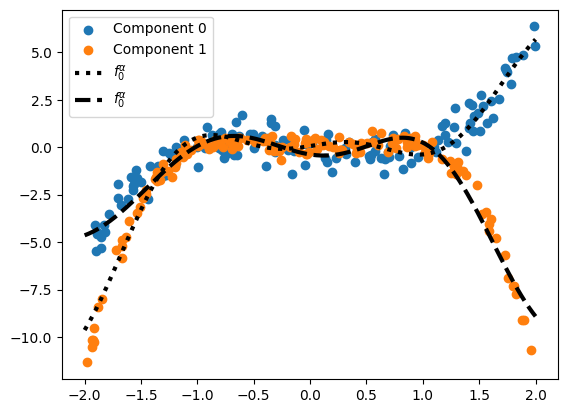

In [ ]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(-2,2,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)
correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
                          sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
                         ) / (2*n)
print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

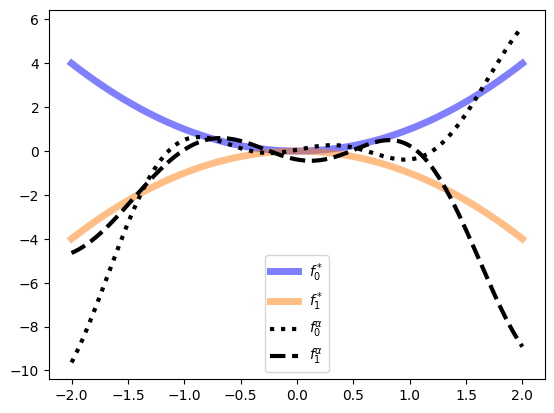

In [ ]:
plt.plot(xx, xx**2, 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, -xx**2, 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5)
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


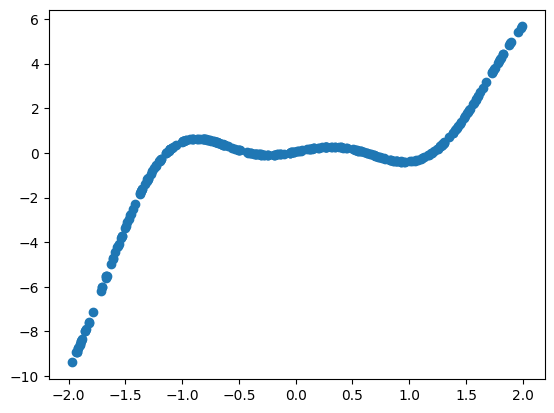

In [ ]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Y_hat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Y_hat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

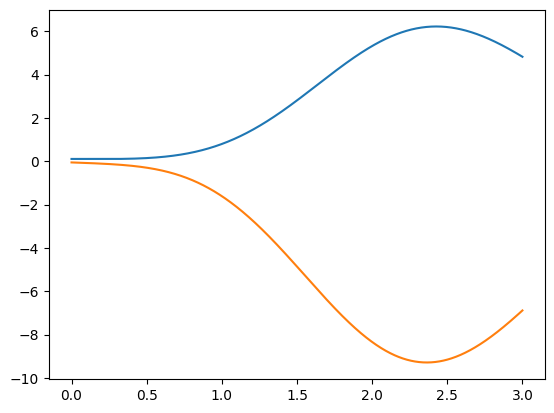

In [ ]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])